# FMA Genre Classifier (High-Recall/Precision Attempt)

This notebook is an aggressive optimization setup for FMA-large:
- Full-track mel cache (one-time)
- Random crop training from full-track mels
- Class-balanced sampling
- Focal loss + label smoothing-style regularization via augmentation
- SpecAugment-like time/frequency masking
- Multi-crop aggregation for validation/test

Important: **80% macro precision/recall on FMA-large top-genre is generally not realistic** with standard CNNs. This notebook is tuned to maximize your odds and push substantially above baseline.


In [15]:
from __future__ import annotations

import json
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler


In [16]:
# ===== Config =====
AUDIO_DIR = Path('fma_large')
METADATA_PATH = Path('fma_metadata/tracks.csv')
CACHE_DIR = Path('.cache/mels_full_29s')
OUTPUT_DIR = Path('outputs/high_recall_precision_run')

SAMPLE_RATE = 22050
PRECOMPUTE_DURATION = 29.0     # full clip cache
TRAIN_CROP_DURATION = 5.0      # random crop duration used in training
EVAL_CROP_DURATION = 5.0       # crop duration for multi-crop eval
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

EPOCHS = 35
BATCH_SIZE = 64
LR = 7e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # notebook-safe on macOS/Python 3.14
SEED = 42
DEVICE_PREF = 'auto'  # auto/cpu/cuda/mps

MAX_TRAIN = None
MAX_VAL = None
MAX_TEST = None

SPLIT_STRATEGY = 'stratified'  # 'stratified' or 'official'
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
MIN_CLASS_COUNT_FOR_SPLIT = 10  # classes below this are dropped before split construction
MIN_TRAIN_COUNT_FOR_MODEL = 120  # drop classes with fewer train samples than this
MERGE_RARE_CLASSES = False      # do not merge low-support classes; drop them
RARE_CLASS_NAME = 'Other'

MIN_AUDIO_FILE_BYTES = 4096
EXCLUDE_BAD_AUDIO_SCAN = True
BAD_AUDIO_SCAN_PATH = Path('outputs/bad_audio_scan.csv')

USE_BALANCED_SAMPLER = True
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0
USE_AUG = True
TIME_MASK_MAX = 24
FREQ_MASK_MAX = 12

VAL_MULTI_CROPS = 5
TEST_MULTI_CROPS = 7

EARLY_STOP_PATIENCE = 8
METRIC_FOR_BEST = 'val_f1_macro'  # can set to 'val_recall_macro'

POSTHOC_TUNE = True
POSTHOC_OBJECTIVE = 'f1_macro'  # choose from compute_metrics keys
POSTHOC_TEMP_VALUES = [0.6, 0.7, 0.8, 0.9, 1.0, 1.2]
POSTHOC_PRIOR_TAU_VALUES = [-0.5, -0.25, 0.0, 0.25, 0.5]
POSTHOC_BIAS_ITERS = 8
POSTHOC_BIAS_STEP = 0.2
POSTHOC_BIAS_STEP_DECAY = 0.5

# Alternate architecture/training preset that follows the other repo's CNN regularization recipe.
MODEL_ARCH = 'res_cnn'  # 'res_cnn' or 'their_cnn2'
THEIR_RECIPE_LR = 1e-4
THEIR_RECIPE_DISABLE_SPEC_AUG = True

CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('CACHE_DIR:', CACHE_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


CACHE_DIR: .cache/mels_full_29s
OUTPUT_DIR: outputs/high_recall_precision_run


In [17]:
# ===== Utilities =====
SPLIT_TRAIN = 'training'
SPLIT_VAL = 'validation'
SPLIT_TEST = 'test'

@dataclass
class TrackRecord:
    track_id: int
    genre: str
    split: str


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def choose_device(device_arg: str) -> torch.device:
    if device_arg == 'cpu':
        return torch.device('cpu')
    if device_arg == 'cuda':
        if not torch.cuda.is_available():
            raise ValueError('Requested cuda but CUDA is unavailable.')
        return torch.device('cuda')
    if device_arg == 'mps':
        if not torch.backends.mps.is_available():
            raise ValueError('Requested mps but MPS is unavailable.')
        return torch.device('mps')
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def optimize_runtime(device: torch.device) -> Dict[str, object]:
    use_amp = False
    amp_dtype = None
    use_channels_last = False
    torch.set_float32_matmul_precision('high')

    if device.type == 'cuda':
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
        use_amp = True
        amp_dtype = torch.float16
        use_channels_last = True
    elif device.type == 'mps':
        use_amp = False
        amp_dtype = None
        use_channels_last = False

    return {'use_amp': use_amp, 'amp_dtype': amp_dtype, 'use_channels_last': use_channels_last}


def track_path(audio_dir: Path, track_id: int) -> Path:
    return audio_dir / f"{track_id:06d}"[:3] / f"{track_id:06d}.mp3"


def cache_key(track_id: int, sample_rate: int, duration: float, n_mels: int, n_fft: int, hop_length: int) -> str:
    return f"{track_id:06d}_sr{sample_rate}_dur{duration}_mel{n_mels}_fft{n_fft}_hop{hop_length}.npy"


def load_records(metadata_path: Path, audio_dir: Path, min_audio_file_bytes: int = 0) -> List[TrackRecord]:
    df = pd.read_csv(metadata_path, header=[0, 1], index_col=0, low_memory=False)
    df.index = df.index.astype(int)

    subset_mask = df[('set', 'subset')] == 'large'
    labeled_mask = df[('track', 'genre_top')].notna()
    filtered = df[subset_mask & labeled_mask]

    out: List[TrackRecord] = []
    skipped_missing = 0
    skipped_tiny = 0

    for track_id, row in filtered.iterrows():
        ap = track_path(audio_dir, int(track_id))
        if not ap.exists():
            skipped_missing += 1
            continue
        if min_audio_file_bytes > 0 and ap.stat().st_size < min_audio_file_bytes:
            skipped_tiny += 1
            continue
        out.append(TrackRecord(int(track_id), str(row[('track', 'genre_top')]), str(row[('set', 'split')])))

    print(f'Loaded labeled records={len(out)} (skipped missing={skipped_missing}, tiny<{min_audio_file_bytes}B={skipped_tiny})')
    return out


def drop_known_bad_audio(records: Sequence[TrackRecord], bad_audio_scan_path: Path, enabled: bool) -> List[TrackRecord]:
    if not enabled:
        return list(records)
    if not bad_audio_scan_path.exists():
        print(f'Bad-audio scan not found: {bad_audio_scan_path}; continuing without extra filtering.')
        return list(records)

    bad = pd.read_csv(bad_audio_scan_path)
    if 'track_id' not in bad.columns:
        print(f'Bad-audio scan missing track_id column: {bad_audio_scan_path}; continuing without extra filtering.')
        return list(records)

    bad_ids = set(bad['track_id'].astype(int).tolist())
    filtered = [r for r in records if r.track_id not in bad_ids]
    print(f'Dropped known bad-audio tracks from scan: {len(records) - len(filtered)}')
    return filtered


def split_records_official(records: Sequence[TrackRecord]) -> Tuple[List[TrackRecord], List[TrackRecord], List[TrackRecord]]:
    train = [TrackRecord(r.track_id, r.genre, SPLIT_TRAIN) for r in records if r.split == SPLIT_TRAIN]
    val = [TrackRecord(r.track_id, r.genre, SPLIT_VAL) for r in records if r.split == SPLIT_VAL]
    test = [TrackRecord(r.track_id, r.genre, SPLIT_TEST) for r in records if r.split == SPLIT_TEST]
    return train, val, test


def split_records_stratified(
    records: Sequence[TrackRecord],
    seed: int,
    train_ratio: float,
    val_ratio: float,
    test_ratio: float,
    min_class_count: int,
) -> Tuple[List[TrackRecord], List[TrackRecord], List[TrackRecord], Dict[str, int]]:
    total = train_ratio + val_ratio + test_ratio
    if abs(total - 1.0) > 1e-8:
        raise ValueError(f'Train/val/test ratios must sum to 1.0, got {total}')

    df = pd.DataFrame([
        {'track_id': r.track_id, 'genre': r.genre, 'split': r.split}
        for r in records
    ])
    counts = df['genre'].value_counts()

    keep_genres = counts[counts >= min_class_count].index.tolist()
    dropped = counts[counts < min_class_count].to_dict()
    df = df[df['genre'].isin(keep_genres)].copy()

    if len(df) == 0:
        raise RuntimeError('No records left after min_class_count filtering; lower MIN_CLASS_COUNT_FOR_SPLIT.')

    idx = np.arange(len(df))
    y = df['genre'].to_numpy()

    train_idx, hold_idx = train_test_split(
        idx,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        shuffle=True,
        stratify=y,
    )

    hold_y = y[hold_idx]
    hold_test_ratio = test_ratio / (val_ratio + test_ratio)
    val_idx, test_idx = train_test_split(
        hold_idx,
        test_size=hold_test_ratio,
        random_state=seed + 1,
        shuffle=True,
        stratify=hold_y,
    )

    def build(ix: np.ndarray, split_name: str) -> List[TrackRecord]:
        chunk = df.iloc[ix]
        return [TrackRecord(int(r.track_id), str(r.genre), split_name) for r in chunk.itertuples(index=False)]

    train = build(train_idx, SPLIT_TRAIN)
    val = build(val_idx, SPLIT_VAL)
    test = build(test_idx, SPLIT_TEST)
    return train, val, test, dropped


def maybe_limit(records: List[TrackRecord], max_items: int | None, seed: int) -> List[TrackRecord]:
    if max_items is None or len(records) <= max_items:
        return records
    rng = random.Random(seed)
    x = records.copy()
    rng.shuffle(x)
    return x[:max_items]


def apply_train_support_policy(
    train_records: Sequence[TrackRecord],
    val_records: Sequence[TrackRecord],
    test_records: Sequence[TrackRecord],
    min_train_count: int,
    merge_rare: bool,
    rare_class_name: str,
) -> Tuple[List[TrackRecord], List[TrackRecord], List[TrackRecord], Dict[str, object]]:
    train = list(train_records)
    val = list(val_records)
    test = list(test_records)

    def counts_of(rs: Sequence[TrackRecord]) -> pd.Series:
        if len(rs) == 0:
            return pd.Series(dtype='int64')
        return pd.Series([r.genre for r in rs]).value_counts().sort_index()

    def relabel(rs: Sequence[TrackRecord], remap: Dict[str, str]) -> List[TrackRecord]:
        out: List[TrackRecord] = []
        for r in rs:
            g = remap.get(r.genre, r.genre)
            out.append(TrackRecord(r.track_id, g, r.split))
        return out

    info: Dict[str, object] = {
        'min_train_count': int(min_train_count),
        'initial_train_counts': counts_of(train).astype(int).to_dict(),
        'rare_classes': {},
        'merged_to': None,
        'dropped_after_policy': {},
        'final_train_counts': {},
    }

    train_counts = counts_of(train)
    rare = train_counts[train_counts < min_train_count]
    info['rare_classes'] = rare.astype(int).to_dict()

    if merge_rare and len(rare) > 0:
        remap = {g: rare_class_name for g in rare.index.tolist()}
        train = relabel(train, remap)
        val = relabel(val, remap)
        test = relabel(test, remap)
        info['merged_to'] = rare_class_name

    post_counts = counts_of(train)
    keep = set(post_counts[post_counts >= min_train_count].index.tolist())
    dropped = post_counts[~post_counts.index.isin(keep)]
    info['dropped_after_policy'] = dropped.astype(int).to_dict()

    if len(dropped) > 0:
        train = [r for r in train if r.genre in keep]
        val = [r for r in val if r.genre in keep]
        test = [r for r in test if r.genre in keep]

    final_counts = counts_of(train)
    if len(final_counts) == 0:
        raise RuntimeError('No classes left after train-support policy; lower MIN_TRAIN_COUNT_FOR_MODEL.')
    info['final_train_counts'] = final_counts.astype(int).to_dict()
    return train, val, test, info


def mel_from_audio(y: np.ndarray, sample_rate: int, target_samples: int, n_mels: int, n_fft: int, hop_length: int) -> np.ndarray:
    if y.shape[0] < target_samples:
        y = np.pad(y, (0, target_samples - y.shape[0]))
    elif y.shape[0] > target_samples:
        y = y[:target_samples]

    mel = librosa.feature.melspectrogram(
        y=y, sr=sample_rate, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmin=20, fmax=sample_rate // 2, power=2.0,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    mean = float(mel_db.mean())
    std = float(mel_db.std())
    return (mel_db - mean) / (std + 1e-6)


def compute_metrics(y_true: Sequence[int], y_pred: Sequence[int], num_classes: int) -> Dict[str, float]:
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_classes)), average='macro', zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_classes)), average='weighted', zero_division=0
    )
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_weighted),
        'recall_weighted': float(r_weighted),
        'f1_weighted': float(f1_weighted),
    }


def class_priors(records: Sequence[TrackRecord], label_to_idx: Dict[str, int]) -> np.ndarray:
    counts = np.zeros(len(label_to_idx), dtype=np.float64)
    for r in records:
        counts[label_to_idx[r.genre]] += 1
    counts = np.maximum(counts, 1.0)
    return counts / counts.sum()


def parse_float_list(spec: str) -> List[float]:
    out: List[float] = []
    for tok in spec.split(','):
        tok = tok.strip()
        if not tok:
            continue
        out.append(float(tok))
    if not out:
        raise ValueError('Expected at least one float value.')
    return out


def cache_status(records: Sequence[TrackRecord], cache_dir: Path) -> Tuple[int, int, List[int]]:
    missing = []
    for rec in records:
        p = cache_dir / cache_key(rec.track_id, SAMPLE_RATE, PRECOMPUTE_DURATION, N_MELS, N_FFT, HOP_LENGTH)
        if not p.exists():
            missing.append(rec.track_id)
    return len(records), len(missing), missing[:10]


In [18]:
# ===== Load data splits + precompute full-track cache =====
records = load_records(METADATA_PATH, AUDIO_DIR, min_audio_file_bytes=MIN_AUDIO_FILE_BYTES)
records = drop_known_bad_audio(records, BAD_AUDIO_SCAN_PATH, enabled=EXCLUDE_BAD_AUDIO_SCAN)
if not records:
    raise RuntimeError('No labeled tracks found after filtering.')

if SPLIT_STRATEGY == 'official':
    train_records, val_records, test_records = split_records_official(records)
    dropped_classes = {}
elif SPLIT_STRATEGY == 'stratified':
    train_records, val_records, test_records, dropped_classes = split_records_stratified(
        records,
        seed=SEED,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
        min_class_count=MIN_CLASS_COUNT_FOR_SPLIT,
    )
else:
    raise ValueError(f'Unknown SPLIT_STRATEGY: {SPLIT_STRATEGY}')

train_records = maybe_limit(train_records, MAX_TRAIN, SEED)
val_records = maybe_limit(val_records, MAX_VAL, SEED + 1)
test_records = maybe_limit(test_records, MAX_TEST, SEED + 2)

train_records, val_records, test_records, support_policy = apply_train_support_policy(
    train_records,
    val_records,
    test_records,
    min_train_count=MIN_TRAIN_COUNT_FOR_MODEL,
    merge_rare=MERGE_RARE_CLASSES,
    rare_class_name=RARE_CLASS_NAME,
)

print(f'split_strategy={SPLIT_STRATEGY}')
print(f'train={len(train_records)} val={len(val_records)} test={len(test_records)}')
if dropped_classes:
    print('Dropped low-count classes for stratified splitting:')
    print(pd.Series(dropped_classes).sort_values().to_string())
if support_policy.get('rare_classes'):
    print(f"Rare classes in train (<{MIN_TRAIN_COUNT_FOR_MODEL}):")
    print(pd.Series(support_policy['rare_classes']).sort_values().to_string())
if support_policy.get('merged_to') is not None:
    print(f"Merged rare classes into: {support_policy['merged_to']}")
if support_policy.get('dropped_after_policy'):
    print('Dropped classes after train-support policy:')
    print(pd.Series(support_policy['dropped_after_policy']).sort_values().to_string())


def print_split_support(train_records, val_records, test_records):
    for split_name, rs in [('train', train_records), ('val', val_records), ('test', test_records)]:
        counts = pd.Series([r.genre for r in rs]).value_counts().sort_index()
        print(f'\n[{split_name}] classes={len(counts)} min={int(counts.min())} median={float(counts.median()):.1f} max={int(counts.max())}')
        print(counts.to_string())

    # Warn on classes with too little data to reliably optimize precision+recall.
    all_counts = pd.Series([r.genre for r in train_records]).value_counts().sort_index()
    tiny = all_counts[all_counts < MIN_TRAIN_COUNT_FOR_MODEL]
    if len(tiny) > 0:
        print(f'\nWarning: very low-support classes in train (<{MIN_TRAIN_COUNT_FOR_MODEL} samples).')
        print(tiny.to_string())
        print('High precision+recall for these classes is statistically unlikely.')


print_split_support(train_records, val_records, test_records)


def precompute_cache(records: Sequence[TrackRecord], cache_dir: Path, overwrite: bool = False, log_every: int = 500):
    cache_dir.mkdir(parents=True, exist_ok=True)
    target_samples = int(SAMPLE_RATE * PRECOMPUTE_DURATION)
    done = skipped = failed = 0

    for i, rec in enumerate(records, start=1):
        out = cache_dir / cache_key(rec.track_id, SAMPLE_RATE, PRECOMPUTE_DURATION, N_MELS, N_FFT, HOP_LENGTH)
        if out.exists() and not overwrite:
            skipped += 1
            continue

        ap = track_path(AUDIO_DIR, rec.track_id)
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore', message='PySoundFile failed. Trying audioread instead.')
                warnings.filterwarnings('ignore', message='librosa.core.audio.__audioread_load')
                y, _ = librosa.load(str(ap), sr=SAMPLE_RATE, mono=True, duration=PRECOMPUTE_DURATION, res_type='kaiser_fast')
            if y is None or y.shape[0] == 0:
                raise ValueError('Decoded empty audio array')
            mel = mel_from_audio(y, SAMPLE_RATE, target_samples, N_MELS, N_FFT, HOP_LENGTH)
            np.save(out, mel)
            done += 1
        except Exception as exc:
            failed += 1
            # Skip corrupted files instead of writing silence features that poison training labels.
            if out.exists():
                out.unlink()
            if failed <= 10 or failed % 50 == 0:
                print(f'Warning: failed {rec.track_id} ({ap}): {exc}; skipping this track.')

        if i % log_every == 0 or i == len(records):
            print(f'[{i}/{len(records)}] written={done} skipped={skipped} failed={failed}')

    print(f'Precompute done: written={done} skipped={skipped} failed={failed} total={len(records)}')


precompute_cache([*train_records, *val_records, *test_records], CACHE_DIR, overwrite=False, log_every=500)

for n, rs in [('train', train_records), ('val', val_records), ('test', test_records)]:
    total, miss, prev = cache_status(rs, CACHE_DIR)
    print(f'{n}: missing={miss} / {total}; preview={prev}')

# Remove tracks still missing cached features (decode failed or absent) from each split.
present = set(int(p.name.split('_')[0]) for p in CACHE_DIR.glob('*.npy'))
train_records = [r for r in train_records if r.track_id in present]
val_records = [r for r in val_records if r.track_id in present]
test_records = [r for r in test_records if r.track_id in present]

print('\nAfter removing missing-cache tracks:')
print(f'train={len(train_records)} val={len(val_records)} test={len(test_records)}')
print_split_support(train_records, val_records, test_records)


Loaded labeled records=24552 (skipped missing=0, tiny<4096B=46)
Dropped known bad-audio tracks from scan: 0
split_strategy=stratified
train=19549 val=2444 test=2444
Dropped low-count classes for stratified splitting:
Easy Listening    3
Rare classes in train (<120):
Country                13
Soul-RnB               17
Blues                  29
Old-Time / Historic    31
Dropped classes after train-support policy:
Country                13
Soul-RnB               17
Blues                  29
Old-Time / Historic    31

[train] classes=11 min=150 median=916.0 max=6682
Classical         489
Electronic       2438
Experimental     6682
Folk             1026
Hip-Hop          1079
Instrumental      582
International     286
Jazz              150
Pop               916
Rock             5659
Spoken            242

[val] classes=11 min=19 median=114.0 max=835
Classical         61
Electronic       304
Experimental     835
Folk             129
Hip-Hop          135
Instrumental      73
International    

In [19]:
# ===== Model, dataset, loss, training, multi-crop evaluation =====
def apply_spec_augment(x: torch.Tensor, time_mask_max: int, freq_mask_max: int) -> torch.Tensor:
    # x: [1, n_mels, T]
    x = x.clone()
    _, f, t = x.shape
    if time_mask_max > 0 and t > 2:
        w = random.randint(0, min(time_mask_max, max(1, t // 4)))
        if w > 0:
            s = random.randint(0, t - w)
            x[:, :, s:s+w] = 0
    if freq_mask_max > 0 and f > 2:
        w = random.randint(0, min(freq_mask_max, max(1, f // 4)))
        if w > 0:
            s = random.randint(0, f - w)
            x[:, s:s+w, :] = 0
    return x


class MelCropDataset(Dataset):
    def __init__(self, records: Sequence[TrackRecord], cache_dir: Path, label_to_idx: Dict[str, int], crop_duration: float, train_mode: bool, use_aug: bool):
        self.records = list(records)
        self.cache_dir = cache_dir
        self.label_to_idx = label_to_idx
        self.train_mode = train_mode
        self.use_aug = use_aug
        self.crop_frames = int(round((crop_duration * SAMPLE_RATE) / HOP_LENGTH))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx: int):
        rec = self.records[idx]
        p = self.cache_dir / cache_key(rec.track_id, SAMPLE_RATE, PRECOMPUTE_DURATION, N_MELS, N_FFT, HOP_LENGTH)
        mel = np.load(p).astype(np.float32)  # [n_mels, T_full]
        T = mel.shape[1]
        c = self.crop_frames

        if T < c:
            pad = np.zeros((mel.shape[0], c - T), dtype=np.float32)
            crop = np.concatenate([mel, pad], axis=1)
        elif T == c:
            crop = mel
        else:
            if self.train_mode:
                start = random.randint(0, T - c)
            else:
                start = (T - c) // 2
            crop = mel[:, start:start+c]

        x = torch.from_numpy(crop).unsqueeze(0)  # [1, n_mels, T_crop]
        if self.train_mode and self.use_aug:
            x = apply_spec_augment(x, TIME_MASK_MAX, FREQ_MASK_MAX)
        y = self.label_to_idx[rec.genre]
        return x, y


class ResidualBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        self.proj = None
        if stride != 1 or c_in != c_out:
            self.proj = nn.Sequential(nn.Conv2d(c_in, c_out, kernel_size=1, stride=stride, bias=False), nn.BatchNorm2d(c_out))

    def forward(self, x):
        identity = x if self.proj is None else self.proj(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity, inplace=True)
        return out


class GenreResCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 192, stride=2)
        self.layer4 = ResidualBlock(192, 256, stride=2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.head(x)


class GenreTheirCNN2(nn.Module):
    """CNN regularization recipe mirrored from the comparison repo's CNN-2 style.
    Conv+BN+Pool+Dropout blocks with a heavier dense dropout head.
    """
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Dropout(0.2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Dropout(0.1),

            nn.Conv2d(64, 64, kernel_size=2, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Dropout(0.1),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)


class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor | None = None, gamma: float = 1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        logp = F.log_softmax(logits, dim=1)
        ce = F.nll_loss(logp, targets, reduction='none')
        pt = torch.exp(-ce)

        focal = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            focal = self.alpha[targets] * focal
        return focal.mean()


def class_weights(records: Sequence[TrackRecord], label_to_idx: Dict[str, int], device: torch.device) -> torch.Tensor:
    counts = np.zeros(len(label_to_idx), dtype=np.float64)
    for r in records:
        counts[label_to_idx[r.genre]] += 1
    counts = np.maximum(counts, 1.0)
    inv = 1.0 / counts
    w = inv / inv.mean()
    return torch.tensor(w, dtype=torch.float32, device=device)


def run_train_epoch(model, loader, criterion, optimizer, device, amp_enabled, amp_dtype, scaler, use_channels_last):
    model.train(True)
    total_loss = 0.0
    y_true, y_pred = [], []

    for xb, yb in loader:
        if use_channels_last:
            xb = xb.contiguous(memory_format=torch.channels_last)
        xb = xb.to(device, non_blocking=(device.type == 'cuda'))
        yb = yb.to(device, non_blocking=(device.type == 'cuda'))

        if amp_enabled:
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=True):
                logits = model(xb)
                loss = criterion(logits, yb)
        else:
            logits = model(xb)
            loss = criterion(logits, yb)

        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(yb.detach().cpu().tolist())
        y_pred.extend(preds.detach().cpu().tolist())

    return total_loss / max(1, len(loader.dataset)), y_true, y_pred


def predict_multicrop(model, rec: TrackRecord, cache_dir: Path, device: torch.device, crop_duration: float, num_crops: int, use_channels_last: bool):
    p = cache_dir / cache_key(rec.track_id, SAMPLE_RATE, PRECOMPUTE_DURATION, N_MELS, N_FFT, HOP_LENGTH)
    mel = np.load(p).astype(np.float32)
    T = mel.shape[1]
    c = int(round((crop_duration * SAMPLE_RATE) / HOP_LENGTH))

    if T <= c:
        starts = [0]
    else:
        starts = np.linspace(0, T - c, num=max(1, num_crops), dtype=int).tolist()

    batch = []
    for s in starts:
        crop = mel[:, s:s+c]
        if crop.shape[1] < c:
            pad = np.zeros((mel.shape[0], c - crop.shape[1]), dtype=np.float32)
            crop = np.concatenate([crop, pad], axis=1)
        x = torch.from_numpy(crop).unsqueeze(0)
        batch.append(x)

    xb = torch.stack(batch, dim=0)
    if use_channels_last:
        xb = xb.contiguous(memory_format=torch.channels_last)
    xb = xb.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(xb)
        mean_logits = logits.mean(dim=0)
    return mean_logits


def predict_from_logits(logits: np.ndarray, temperature: float = 1.0, class_bias: np.ndarray | None = None) -> np.ndarray:
    if temperature <= 0:
        raise ValueError('temperature must be > 0')
    z = logits / float(temperature)
    if class_bias is not None:
        z = z + class_bias[None, :]
    return z.argmax(axis=1).astype(np.int64)


def metrics_from_logits(
    logits: np.ndarray,
    y_true: Sequence[int],
    num_classes: int,
    temperature: float = 1.0,
    class_bias: np.ndarray | None = None,
):
    pred = predict_from_logits(logits, temperature=temperature, class_bias=class_bias)
    metrics = compute_metrics(y_true, pred.tolist(), num_classes)
    return metrics, pred.tolist()


def tune_posthoc(
    logits: np.ndarray,
    y_true: Sequence[int],
    objective: str,
    temp_values: Sequence[float],
    prior_tau_values: Sequence[float],
    log_priors: np.ndarray,
    bias_iters: int,
    bias_step: float,
    bias_step_decay: float,
):
    num_classes = logits.shape[1]
    best_temp = 1.0
    best_tau = 0.0
    best_bias = np.zeros(num_classes, dtype=np.float32)
    best_metrics, _ = metrics_from_logits(logits, y_true, num_classes)
    best_score = best_metrics[objective]

    for t in temp_values:
        for tau in prior_tau_values:
            bias = (float(tau) * log_priors).astype(np.float32)
            m, _ = metrics_from_logits(logits, y_true, num_classes, temperature=t, class_bias=bias)
            s = m[objective]
            if s > best_score:
                best_score = s
                best_temp = float(t)
                best_tau = float(tau)
                best_bias = bias
                best_metrics = m

    step = float(bias_step)
    current_bias = best_bias.copy()
    for _ in range(max(0, bias_iters)):
        improved = False
        for c in range(num_classes):
            for delta in (step, -step):
                cand = current_bias.copy()
                cand[c] += float(delta)
                m, _ = metrics_from_logits(logits, y_true, num_classes, temperature=best_temp, class_bias=cand)
                s = m[objective]
                if s > best_score:
                    best_score = s
                    best_bias = cand
                    current_bias = cand
                    best_metrics = m
                    improved = True
        step *= float(bias_step_decay)
        if not improved and step < 1e-4:
            break

    return best_temp, best_tau, best_bias, best_metrics


def collect_multicrop_logits(
    model,
    records: Sequence[TrackRecord],
    label_to_idx: Dict[str, int],
    device: torch.device,
    num_crops: int,
    use_channels_last: bool,
):
    logits_rows, y_true = [], []
    for i, rec in enumerate(records, start=1):
        mean_logits = predict_multicrop(model, rec, CACHE_DIR, device, EVAL_CROP_DURATION, num_crops, use_channels_last)
        logits_rows.append(mean_logits.detach().cpu().numpy().astype(np.float32))
        y_true.append(label_to_idx[rec.genre])
        if i % 500 == 0 or i == len(records):
            print(f'eval progress: {i}/{len(records)}')
    return np.stack(logits_rows, axis=0), y_true


def evaluate_multicrop(
    model,
    records: Sequence[TrackRecord],
    label_to_idx: Dict[str, int],
    device: torch.device,
    num_crops: int,
    use_channels_last: bool,
    temperature: float = 1.0,
    class_bias: np.ndarray | None = None,
):
    logits, y_true = collect_multicrop_logits(model, records, label_to_idx, device, num_crops, use_channels_last)
    metrics, y_pred = metrics_from_logits(
        logits,
        y_true,
        len(label_to_idx),
        temperature=temperature,
        class_bias=class_bias,
    )
    return metrics, y_true, y_pred


set_seed(SEED)
device = choose_device(DEVICE_PREF)
runtime = optimize_runtime(device)
scaler = torch.amp.GradScaler('cuda', enabled=(runtime['use_amp'] and device.type == 'cuda'))

all_genres = sorted({r.genre for r in [*train_records, *val_records, *test_records]})
label_to_idx = {g: i for i, g in enumerate(all_genres)}
idx_to_label = {i: g for g, i in label_to_idx.items()}

# preflight cache
for split_name, rs in [('train', train_records), ('val', val_records), ('test', test_records)]:
    total, miss, prev = cache_status(rs, CACHE_DIR)
    if miss > 0:
        raise FileNotFoundError(f'Cache incomplete: {split_name} missing={miss}, preview={prev}')

effective_use_aug = USE_AUG
if MODEL_ARCH == 'their_cnn2' and THEIR_RECIPE_DISABLE_SPEC_AUG:
    effective_use_aug = False

train_ds = MelCropDataset(train_records, CACHE_DIR, label_to_idx, TRAIN_CROP_DURATION, train_mode=True, use_aug=effective_use_aug)

if USE_BALANCED_SAMPLER:
    counts = np.zeros(len(label_to_idx), dtype=np.float64)
    for r in train_records:
        counts[label_to_idx[r.genre]] += 1
    sample_weights = [1.0 / counts[label_to_idx[r.genre]] for r in train_records]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_records), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

if MODEL_ARCH == 'res_cnn':
    model = GenreResCNN(num_classes=len(all_genres)).to(device)
elif MODEL_ARCH == 'their_cnn2':
    model = GenreTheirCNN2(num_classes=len(all_genres)).to(device)
else:
    raise ValueError(f'Unknown MODEL_ARCH: {MODEL_ARCH}')
if runtime['use_channels_last']:
    model = model.to(memory_format=torch.channels_last)

cw = class_weights(train_records, label_to_idx, device)

# Avoid double rebalancing: if sampling is already balanced, use unweighted loss.
if USE_BALANCED_SAMPLER:
    loss_alpha = None
    ce_weight = None
else:
    loss_alpha = cw
    ce_weight = cw

criterion = FocalLoss(alpha=loss_alpha, gamma=FOCAL_GAMMA) if USE_FOCAL_LOSS else nn.CrossEntropyLoss(weight=ce_weight)
effective_lr = THEIR_RECIPE_LR if MODEL_ARCH == 'their_cnn2' else LR
optimizer = optim.AdamW(model.parameters(), lr=effective_lr, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

history = []
best_score = -1.0
best_ckpt = OUTPUT_DIR / 'best_model.pt'
no_improve = 0

print('Using device:', device)
print('Runtime:', runtime)
print('Classes:', len(all_genres))
print('MODEL_ARCH:', MODEL_ARCH)
print('effective_lr:', effective_lr)
print('effective_use_aug:', effective_use_aug)

for epoch in range(1, EPOCHS + 1):
    tr_loss, ytr, ptr = run_train_epoch(
        model, train_loader, criterion, optimizer, device,
        runtime['use_amp'], runtime['amp_dtype'], scaler, runtime['use_channels_last']
    )
    tr_metrics = compute_metrics(ytr, ptr, len(all_genres))

    val_metrics, _, _ = evaluate_multicrop(
        model, val_records, label_to_idx, device,
        num_crops=VAL_MULTI_CROPS,
        use_channels_last=runtime['use_channels_last'],
    )

    scheduler.step(val_metrics['f1_macro'])

    row = {
        'epoch': epoch,
        'train_loss': tr_loss,
        'train_accuracy': tr_metrics['accuracy'],
        'train_precision_macro': tr_metrics['precision_macro'],
        'train_recall_macro': tr_metrics['recall_macro'],
        'train_f1_macro': tr_metrics['f1_macro'],
        'val_accuracy': val_metrics['accuracy'],
        'val_precision_macro': val_metrics['precision_macro'],
        'val_recall_macro': val_metrics['recall_macro'],
        'val_f1_macro': val_metrics['f1_macro'],
        'val_precision_weighted': val_metrics['precision_weighted'],
        'val_recall_weighted': val_metrics['recall_weighted'],
        'val_f1_weighted': val_metrics['f1_weighted'],
        'lr': float(optimizer.param_groups[0]['lr']),
    }
    history.append(row)

    score = row[METRIC_FOR_BEST]
    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"train_f1={row['train_f1_macro']:.4f} "
        f"val_f1={row['val_f1_macro']:.4f} "
        f"val_prec={row['val_precision_macro']:.4f} "
        f"val_rec={row['val_recall_macro']:.4f}"
    )

    if score > best_score:
        best_score = score
        no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'label_to_idx': label_to_idx,
            'idx_to_label': idx_to_label,
            'config': {
                'sample_rate': SAMPLE_RATE,
                'precompute_duration': PRECOMPUTE_DURATION,
                'eval_crop_duration': EVAL_CROP_DURATION,
                'n_mels': N_MELS,
                'n_fft': N_FFT,
                'hop_length': HOP_LENGTH,
                'val_multi_crops': VAL_MULTI_CROPS,
                'test_multi_crops': TEST_MULTI_CROPS,
                'model_arch': MODEL_ARCH,
                'use_aug': effective_use_aug,
            },
            'epoch': epoch,
            'best_metric': METRIC_FOR_BEST,
            'best_score': best_score,
            'val_metrics': val_metrics,
        }, best_ckpt)
    else:
        no_improve += 1

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

hist_df = pd.DataFrame(history)
hist_df.to_csv(OUTPUT_DIR / 'history.csv', index=False)
print('Training complete. Best score:', best_score)


Using device: mps
Runtime: {'use_amp': False, 'amp_dtype': None, 'use_channels_last': False}
Classes: 11
MODEL_ARCH: res_cnn
effective_lr: 0.0007
effective_use_aug: True
eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
Epoch 01/35 train_f1=0.3660 val_f1=0.2782 val_prec=0.3561 val_rec=0.3793
eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
Epoch 02/35 train_f1=0.4477 val_f1=0.3632 val_prec=0.3772 val_rec=0.4641
eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
Epoch 03/35 train_f1=0.4869 val_f1=0.3857 val_prec=0.3761 val_rec=0.5307
eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
Epoch 04/35 train_f1=0.5183 val_f1=0.4073 val_prec=0.4091 val_rec=0.5275
eval progress: 500/2444
eval progress: 100

eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
eval progress: 500/2444
eval progress: 1000/2444
eval progress: 1500/2444
eval progress: 2000/2444
eval progress: 2444/2444
POSTHOC_VAL: {'accuracy': 0.6788052373158756, 'precision_macro': 0.6506929428573809, 'recall_macro': 0.5740427909812548, 'f1_macro': 0.5849796265734187, 'precision_weighted': 0.6951084775156593, 'recall_weighted': 0.6788052373158756, 'f1_weighted': 0.6816865189055041}
POSTHOC_TEST: {'accuracy': 0.6734860883797054, 'precision_macro': 0.6114719047212704, 'recall_macro': 0.5900255515076522, 'f1_macro': 0.5887790742711922, 'precision_weighted': 0.6881569414670498, 'recall_weighted': 0.6734860883797054, 

,epoch,train_loss,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,lr
30,31,0.247514,0.846846,0.846821,0.847584,0.846977,0.675123,0.624227,0.564930,0.571125,0.687945,0.675123,0.677200,0.000087
31,32,0.248290,0.844749,0.844086,0.844973,0.844181,0.659165,0.628414,0.564491,0.566775,0.674452,0.659165,0.660049,0.000087
32,33,0.241552,0.844289,0.844929,0.845425,0.844896,0.671031,0.642286,0.562657,0.571822,0.682373,0.671031,0.671821,0.000044
33,34,0.236143,0.848688,0.848178,0.848849,0.848232,0.673895,0.632191,0.561809,0.572244,0.688844,0.673895,0.675951,0.000044
34,35,0.221697,0.858509,0.857661,0.858116,0.857608,0.669804,0.641744,0.566237,0.573257,0.687227,0.669804,0.672529,0.000044


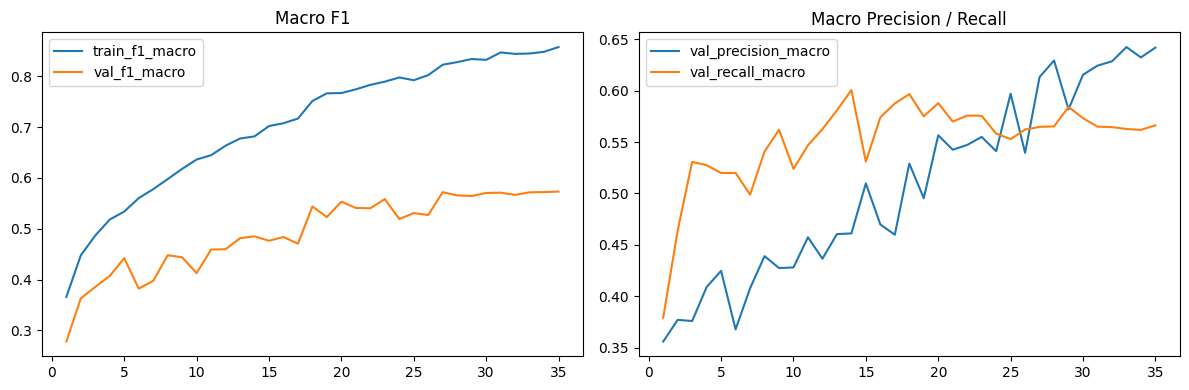

In [20]:
# ===== Final test evaluation (multi-crop) + reporting =====
ckpt = torch.load(OUTPUT_DIR / 'best_model.pt', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])

ckpt_label_to_idx = ckpt['label_to_idx']
ckpt_idx_to_label = ckpt.get('idx_to_label', {v: k for k, v in ckpt_label_to_idx.items()})
if ckpt_label_to_idx != label_to_idx:
    raise RuntimeError('Label mapping mismatch between current session and checkpoint. Re-run training/data cells.')

val_metrics, _, _ = evaluate_multicrop(
    model, val_records, ckpt_label_to_idx, device,
    num_crops=VAL_MULTI_CROPS,
    use_channels_last=runtime['use_channels_last'],
)

test_metrics, y_te, p_te = evaluate_multicrop(
    model, test_records, ckpt_label_to_idx, device,
    num_crops=TEST_MULTI_CROPS,
    use_channels_last=runtime['use_channels_last'],
)

cm = confusion_matrix(y_te, p_te, labels=list(range(len(ckpt_label_to_idx))))
np.save(OUTPUT_DIR / 'test_confusion_matrix.npy', cm)

summary = {
    'best_metric': ckpt['best_metric'],
    'best_score': ckpt['best_score'],
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'checkpoint': str(OUTPUT_DIR / 'best_model.pt'),
}

if POSTHOC_TUNE:
    val_logits, y_val = collect_multicrop_logits(
        model, val_records, ckpt_label_to_idx, device,
        num_crops=VAL_MULTI_CROPS,
        use_channels_last=runtime['use_channels_last'],
    )
    test_logits, y_test = collect_multicrop_logits(
        model, test_records, ckpt_label_to_idx, device,
        num_crops=TEST_MULTI_CROPS,
        use_channels_last=runtime['use_channels_last'],
    )

    train_priors = class_priors(train_records, ckpt_label_to_idx)
    log_priors = np.log(np.clip(train_priors, 1e-8, 1.0)).astype(np.float32)

    best_temp, best_tau, best_bias, posthoc_val_metrics = tune_posthoc(
        val_logits,
        y_val,
        objective=POSTHOC_OBJECTIVE,
        temp_values=POSTHOC_TEMP_VALUES if isinstance(POSTHOC_TEMP_VALUES, list) else parse_float_list(POSTHOC_TEMP_VALUES),
        prior_tau_values=POSTHOC_PRIOR_TAU_VALUES if isinstance(POSTHOC_PRIOR_TAU_VALUES, list) else parse_float_list(POSTHOC_PRIOR_TAU_VALUES),
        log_priors=log_priors,
        bias_iters=POSTHOC_BIAS_ITERS,
        bias_step=POSTHOC_BIAS_STEP,
        bias_step_decay=POSTHOC_BIAS_STEP_DECAY,
    )
    posthoc_test_metrics, p_te_posthoc = metrics_from_logits(
        test_logits,
        y_test,
        len(ckpt_label_to_idx),
        temperature=best_temp,
        class_bias=best_bias,
    )

    print('POSTHOC_VAL:', posthoc_val_metrics)
    print('POSTHOC_TEST:', posthoc_test_metrics)
    print(f'POSTHOC_PARAMS: temp={best_temp:.4f} prior_tau={best_tau:.4f}')
    print('Classification report (test, posthoc):')
    print(
        classification_report(
            y_test,
            p_te_posthoc,
            labels=list(range(len(ckpt_label_to_idx))),
            target_names=[ckpt_idx_to_label[i] for i in range(len(ckpt_label_to_idx))],
            digits=4,
            zero_division=0,
        )
    )

    cm_posthoc = confusion_matrix(y_test, p_te_posthoc, labels=list(range(len(ckpt_label_to_idx))))
    np.save(OUTPUT_DIR / 'test_confusion_matrix_posthoc.npy', cm_posthoc)

    summary['posthoc'] = {
        'objective': POSTHOC_OBJECTIVE,
        'temperature': float(best_temp),
        'prior_tau': float(best_tau),
        'class_bias': [float(x) for x in best_bias.tolist()],
        'val_metrics': posthoc_val_metrics,
        'test_metrics': posthoc_test_metrics,
    }

(OUTPUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('VAL:', val_metrics)
print('TEST:', test_metrics)
print('Classification report (test):')
print(
    classification_report(
        y_te,
        p_te,
        labels=list(range(len(ckpt_label_to_idx))),
        target_names=[ckpt_idx_to_label[i] for i in range(len(ckpt_label_to_idx))],
        digits=4,
        zero_division=0,
    )
)

hist = pd.read_csv(OUTPUT_DIR / 'history.csv')
display(hist.tail())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist['epoch'], hist['train_f1_macro'], label='train_f1_macro')
ax[0].plot(hist['epoch'], hist['val_f1_macro'], label='val_f1_macro')
ax[0].set_title('Macro F1')
ax[0].legend()

ax[1].plot(hist['epoch'], hist['val_precision_macro'], label='val_precision_macro')
ax[1].plot(hist['epoch'], hist['val_recall_macro'], label='val_recall_macro')
ax[1].set_title('Macro Precision / Recall')
ax[1].legend()

plt.tight_layout()
plt.show()


In [21]:
# ===== Single-file inference helper =====
def _build_model_from_checkpoint_config(config: Dict[str, object], state_dict: Dict[str, torch.Tensor], num_classes: int):
    arch = str(config.get('model_arch', '')).strip().lower()
    if not arch:
        # Backward-compatible fallback for older checkpoints: infer by key pattern.
        if any(k.startswith('features.') for k in state_dict.keys()):
            arch = 'their_cnn2'
        else:
            arch = 'res_cnn'

    if arch == 'res_cnn':
        return GenreResCNN(num_classes=num_classes), arch
    if arch == 'their_cnn2':
        return GenreTheirCNN2(num_classes=num_classes), arch
    raise ValueError(f'Unsupported model_arch in checkpoint: {arch}')


def predict_file(audio_file: str, checkpoint_path: Path, top_k: int = 5):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    l2i = checkpoint['label_to_idx']
    i2l = checkpoint.get('idx_to_label', {v:k for k,v in l2i.items()})
    cfg = checkpoint.get('config', {})

    sr = int(cfg.get('sample_rate', SAMPLE_RATE))
    dur = float(cfg.get('precompute_duration', PRECOMPUTE_DURATION))
    crop_dur = float(cfg.get('eval_crop_duration', EVAL_CROP_DURATION))
    n_mels = int(cfg.get('n_mels', N_MELS))
    n_fft = int(cfg.get('n_fft', N_FFT))
    hop = int(cfg.get('hop_length', HOP_LENGTH))
    n_crops = int(cfg.get('test_multi_crops', TEST_MULTI_CROPS))

    model, ckpt_arch = _build_model_from_checkpoint_config(cfg, checkpoint['model_state_dict'], num_classes=len(l2i))
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f'Loaded checkpoint arch: {ckpt_arch}')

    y, _ = librosa.load(audio_file, sr=sr, mono=True, duration=dur, res_type='kaiser_fast')
    full = mel_from_audio(y, sr, int(sr * dur), n_mels, n_fft, hop)

    T = full.shape[1]
    c = int(round((crop_dur * sr) / hop))
    starts = [0] if T <= c else np.linspace(0, T - c, num=max(1, n_crops), dtype=int).tolist()

    batch = []
    for s in starts:
        crop = full[:, s:s+c]
        if crop.shape[1] < c:
            pad = np.zeros((full.shape[0], c - crop.shape[1]), dtype=np.float32)
            crop = np.concatenate([crop, pad], axis=1)
        batch.append(torch.from_numpy(crop).unsqueeze(0))

    xb = torch.stack(batch, dim=0)
    with torch.no_grad():
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).mean(dim=0).cpu().numpy()

    top = np.argsort(probs)[::-1][:top_k]
    return [(i2l[int(i)], float(probs[int(i)])) for i in top]


preds = predict_file('fma_large/002/002003.mp3', OUTPUT_DIR / 'best_model.pt', top_k=5)
for label, p in preds:
    print(f'{label:20s} {p:.4f}')


Loaded checkpoint arch: res_cnn
Experimental         0.5245
Spoken               0.1686
Pop                  0.0798
Folk                 0.0717
Electronic           0.0567
